# Notebook 2 – Adult Income (Binary Classification)

## Overview
We benchmark six tabular-learning methods on the UCI Adult Income dataset:
**TabNet**, **FT-Transformer**, **XGBoost**, **LightGBM**, **Random Forest**,
and **Logistic Regression**.  
Each model is tuned with **Optuna** (20 trials) and evaluated across 3 seeds.  
Metrics: **Accuracy**, **AUC-ROC**, **F1**.


In [ ]:
!pip install pytorch-tabnet "rtdl==0.0.13" optuna xgboost lightgbm ucimlrepo scikit-learn pandas numpy matplotlib seaborn shap

## Imports

In [8]:
import warnings
warnings.filterwarnings('ignore')

import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from rtdl_revisiting_models import MLP, ResNet, FTTransformer
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

from pytorch_tabnet.tab_model import TabNetClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## Configuration

In [9]:
SEEDS           = [42, 123, 456]
N_OPTUNA_TRIALS = 20
TEST_SIZE       = 0.20
VAL_FRAC        = 0.25


## Data Loading & EDA

In [10]:
adult = fetch_ucirepo(id=2)
X_raw = adult.data.features.copy()
y_raw = adult.data.targets.copy()

print("Features shape:", X_raw.shape)
print()
print(X_raw.dtypes)
print()
print(X_raw.describe())


Features shape: (48842, 14)

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
dtype: object

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
mean      38.643585  1.896641e+05      10.078089   1079.067626     87.502314   
std       13.710510  1.056040e+05       2.570973   7452.019058    403.004552   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.175505e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.781445e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.376420e+05      12.0000

In [11]:
# Target distribution
target_series = y_raw.iloc[:, 0].astype(str).str.strip()
print("Unique target values:", target_series.unique())
print(target_series.value_counts())


Unique target values: ['<=50K' '>50K' '<=50K.' '>50K.']
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64


In [12]:
# Missing value overview
print("Missing values (including '?'):")
for col in X_raw.columns:
    n = (X_raw[col].astype(str).str.strip() == '?').sum()
    if n > 0:
        print(f"  {col}: {n}")


Missing values (including '?'):
  workclass: 1836
  occupation: 1843
  native-country: 583


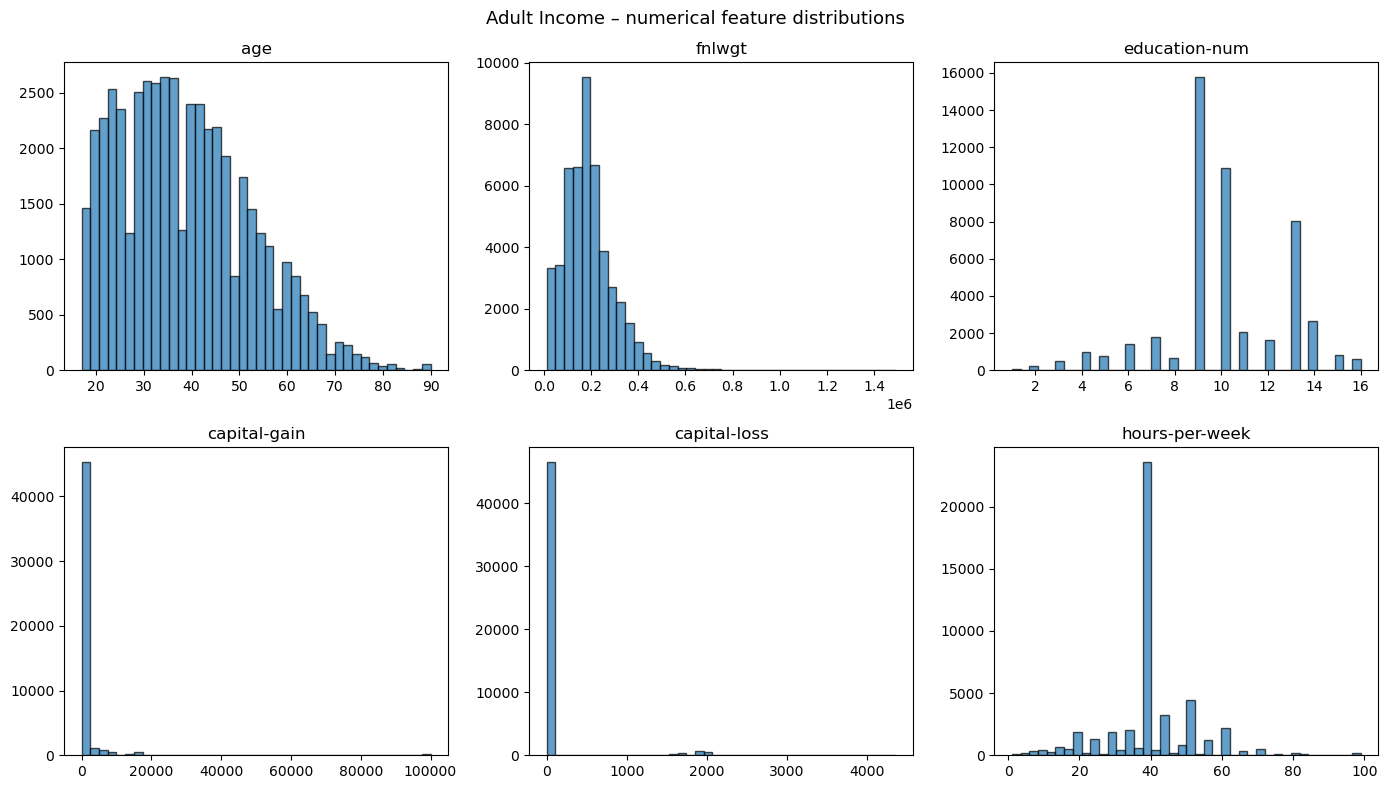

In [25]:
# Distribution plots for numeric columns
num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(X_raw[col].dropna(), bins=40, edgecolor='k', alpha=0.7)
    ax.set_title(col)
plt.suptitle("Adult Income – numerical feature distributions", fontsize=13)
plt.tight_layout()
plt.show()


## Preprocessing

In [30]:
# Raw columns
num_cols_raw = ['age', 'fnlwgt', 'education-num', 'capital-gain',
                'capital-loss', 'hours-per-week']

cat_cols = ['workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'sex', 'native-country']

In [31]:
y_series = y_raw.iloc[:, 0].astype(str).str.strip().str.replace('.', '', regex=False)
y = np.where(y_series == '>50K', 1, 0).astype(np.int64)

print(f"Positive rate: {y.mean():.3%}")
print(pd.Series(y).value_counts())

Positive rate: 23.928%
0    37155
1    11687
Name: count, dtype: int64


In [32]:
X_proc = X_raw.copy()

# Replace '?' with NaN in categorical columns
for col in cat_cols:
    X_proc[col] = X_proc[col].astype(str).str.strip().replace('?', np.nan)

# Impute numeric columns with median
for col in num_cols_raw:
    X_proc[col] = X_proc[col].fillna(X_proc[col].median())

# Impute categorical columns with 'Unknown'
for col in cat_cols:
    X_proc[col] = X_proc[col].fillna('Unknown')

# Feature engineering
X_proc['capital-gain'] = np.log1p(X_proc['capital-gain'])
X_proc['capital-loss'] = np.log1p(X_proc['capital-loss'])

X_proc['has_capital_gain'] = (X_proc['capital-gain'] > 0).astype(int)
X_proc['has_capital_loss'] = (X_proc['capital-loss'] > 0).astype(int)

# Drop fnlwgt
X_proc = X_proc.drop(columns=['fnlwgt'])

print("Missing after preprocessing:", X_proc.isnull().sum().sum())
print(X_proc.head())

Missing after preprocessing: 0
   age         workclass  education  education-num      marital-status  \
0   39         State-gov  Bachelors             13       Never-married   
1   50  Self-emp-not-inc  Bachelors             13  Married-civ-spouse   
2   38           Private    HS-grad              9            Divorced   
3   53           Private       11th              7  Married-civ-spouse   
4   28           Private  Bachelors             13  Married-civ-spouse   

          occupation   relationship   race     sex  capital-gain  \
0       Adm-clerical  Not-in-family  White    Male      7.684784   
1    Exec-managerial        Husband  White    Male      0.000000   
2  Handlers-cleaners  Not-in-family  White    Male      0.000000   
3  Handlers-cleaners        Husband  Black    Male      0.000000   
4     Prof-specialty           Wife  Black  Female      0.000000   

   capital-loss  hours-per-week native-country  has_capital_gain  \
0           0.0              40  United-States 

In [33]:
# Define final column groups after preprocessing
num_cols = ['age', 'education-num', 'capital-gain',
            'capital-loss', 'hours-per-week',
            'has_capital_gain', 'has_capital_loss']

cat_cols = ['workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'sex', 'native-country']

## Data Splitting (60 / 20 / 20)

In [34]:
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X_proc, y, test_size=0.4, random_state=42, stratify=y
)

X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train_df.shape, "Val:", X_val_df.shape, "Test:", X_test_df.shape)
print("y_train distribution:\n", pd.Series(y_train).value_counts(normalize=True))
print("y_val distribution:\n", pd.Series(y_val).value_counts(normalize=True))
print("y_test distribution:\n", pd.Series(y_test).value_counts(normalize=True))

Train: (29305, 15) Val: (9768, 15) Test: (9769, 15)
y_train distribution:
 0    0.760723
1    0.239277
Name: proportion, dtype: float64
y_val distribution:
 0    0.760749
1    0.239251
Name: proportion, dtype: float64
y_test distribution:
 0    0.760672
1    0.239328
Name: proportion, dtype: float64


In [35]:
# Classical models pipeline - logistics regression, random forest, xgboost, lightgbm

X_train_c = pd.get_dummies(X_train_df, drop_first=True)
X_val_c = pd.get_dummies(X_val_df, drop_first=True)
X_test_c = pd.get_dummies(X_test_df, drop_first=True)

# Align val/test columns to train columns
X_val_c = X_val_c.reindex(columns=X_train_c.columns, fill_value=0)
X_test_c = X_test_c.reindex(columns=X_train_c.columns, fill_value=0)

print("Classical shapes:")
print("Train:", X_train_c.shape)
print("Val:  ", X_val_c.shape)
print("Test: ", X_test_c.shape)

Classical shapes:
Train: (29305, 104)
Val:   (9768, 104)
Test:  (9769, 104)


In [36]:
# Deep learning pipeline TabNet, FT-Transformer

ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_cat = ord_enc.fit_transform(X_train_df[cat_cols]).astype(np.int64)
X_val_cat = ord_enc.transform(X_val_df[cat_cols]).astype(np.int64)
X_test_cat = ord_enc.transform(X_test_df[cat_cols]).astype(np.int64)

# Shift so unknown becomes 0 instead of -1
X_train_cat = X_train_cat + 1
X_val_cat = X_val_cat + 1
X_test_cat = X_test_cat + 1

scaler_num = StandardScaler()
X_train_num = scaler_num.fit_transform(X_train_df[num_cols].astype(np.float32))
X_val_num = scaler_num.transform(X_val_df[num_cols].astype(np.float32))
X_test_num = scaler_num.transform(X_test_df[num_cols].astype(np.float32))

cat_cardinalities = [len(cats) + 1 for cats in ord_enc.categories_]

print("DL numeric shapes:")
print("Train:", X_train_num.shape)
print("Val:  ", X_val_num.shape)
print("Test: ", X_test_num.shape)

print("DL categorical shapes:")
print("Train:", X_train_cat.shape)
print("Val:  ", X_val_cat.shape)
print("Test: ", X_test_cat.shape)

print("Cat cardinalities:", cat_cardinalities)

DL numeric shapes:
Train: (29305, 7)
Val:   (9768, 7)
Test:  (9769, 7)
DL categorical shapes:
Train: (29305, 8)
Val:   (9768, 8)
Test:  (9769, 8)
Cat cardinalities: [11, 17, 8, 17, 7, 6, 3, 44]


In [37]:
# Combined matrix for TabNet

X_train_dl_all = np.concatenate([X_train_num, X_train_cat.astype(np.float32)], axis=1)
X_val_dl_all = np.concatenate([X_val_num, X_val_cat.astype(np.float32)], axis=1)
X_test_dl_all = np.concatenate([X_test_num, X_test_cat.astype(np.float32)], axis=1)

print("Combined DL shapes:")
print("Train:", X_train_dl_all.shape)
print("Val:  ", X_val_dl_all.shape)
print("Test: ", X_test_dl_all.shape)

Combined DL shapes:
Train: (29305, 15)
Val:   (9768, 15)
Test:  (9769, 15)


## Helper Functions

In [38]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def compute_classification_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, auc, f1


def train_ft_transformer(
    model,
    X_num_tr, X_cat_tr, y_tr,
    X_num_v, X_cat_v, y_v,
    lr=1e-3, n_epochs=100, batch_size=256,
    device_='cpu', patience=20
):
    model = model.to(device_)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()

    X_num_tr_t = torch.FloatTensor(X_num_tr).to(device_)
    X_cat_tr_t = torch.LongTensor(X_cat_tr).to(device_) if X_cat_tr is not None else None
    y_tr_t = torch.FloatTensor(y_tr.astype(np.float32)).to(device_)

    X_num_v_t = torch.FloatTensor(X_num_v).to(device_)
    X_cat_v_t = torch.LongTensor(X_cat_v).to(device_) if X_cat_v is not None else None
    y_v_t = torch.FloatTensor(y_v.astype(np.float32)).to(device_)

    train_losses, val_losses = [], []
    best_val = float('inf')
    best_state = None
    pat_cnt = 0

    for epoch in range(n_epochs):
        model.train()
        n = len(X_num_tr_t)
        idx = torch.randperm(n)
        ep_loss = 0.0

        for i in range(0, n, batch_size):
            b = idx[i:i + batch_size]
            xn = X_num_tr_t[b]
            xc = X_cat_tr_t[b] if X_cat_tr_t is not None else None
            yb = y_tr_t[b]

            optimizer.zero_grad()
            out = model(xn, xc).squeeze(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            ep_loss += loss.item() * len(b)

        model.eval()
        with torch.no_grad():
            vout = model(X_num_v_t, X_cat_v_t).squeeze(-1)
            vloss = criterion(vout, y_v_t).item()

        train_losses.append(ep_loss / n)
        val_losses.append(vloss)

        if vloss < best_val:
            best_val = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt = 0
        else:
            pat_cnt += 1

        if pat_cnt >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses


def predict_ft_transformer(model, X_num, X_cat, device_, batch_size=512):
    model.eval()
    model = model.to(device_)

    X_num_t = torch.FloatTensor(X_num).to(device_)
    X_cat_t = torch.LongTensor(X_cat).to(device_) if X_cat is not None else None

    logits = []
    probs = []

    with torch.no_grad():
        for i in range(0, len(X_num_t), batch_size):
            xn = X_num_t[i:i + batch_size]
            xc = X_cat_t[i:i + batch_size] if X_cat_t is not None else None

            out = model(xn, xc).squeeze(-1)
            pr = torch.sigmoid(out)

            logits.append(out.cpu().numpy())
            probs.append(pr.cpu().numpy())

    logits = np.concatenate(logits)
    probs = np.concatenate(probs)
    preds = (probs >= 0.5).astype(int)

    return logits, probs, preds

## Model 1: TabNet

In [39]:
all_results = []

def tabnet_clf_objective(trial):
    n_d = trial.suggest_int('n_d', 8, 64)
    n_a = trial.suggest_int('n_a', 8, 64)
    n_steps = trial.suggest_int('n_steps', 3, 10)
    gamma = trial.suggest_float('gamma', 1.0, 2.0)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    set_seed(42)

    m = TabNetClassifier(
        n_d=n_d,
        n_a=n_a,
        n_steps=n_steps,
        gamma=gamma,
        optimizer_params={'lr': lr},
        verbose=0,
        seed=42,
        device_name='cuda' if torch.cuda.is_available() else 'cpu'
    )

    m.fit(
        X_train_dl_all, y_train.astype(int),
        eval_set=[(X_val_dl_all, y_val.astype(int))],
        eval_name=['val'],
        eval_metric=['auc'],
        patience=15,
        max_epochs=100,
        batch_size=1024,
        virtual_batch_size=256
    )

    prob = m.predict_proba(X_val_dl_all)[:, 1]
    return roc_auc_score(y_val, prob)


study_tn = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_tn.optimize(tabnet_clf_objective, n_trials=N_OPTUNA_TRIALS)
best_tn = study_tn.best_params
print(f"Best TabNet params: {best_tn}")


Early stopping occurred at epoch 70 with best_epoch = 55 and best_val_auc = 0.87336

Early stopping occurred at epoch 45 with best_epoch = 30 and best_val_auc = 0.88286
Stop training because you reached max_epochs = 100 with best_epoch = 98 and best_val_auc = 0.8817

Early stopping occurred at epoch 91 with best_epoch = 76 and best_val_auc = 0.87947

Early stopping occurred at epoch 80 with best_epoch = 65 and best_val_auc = 0.89647
Stop training because you reached max_epochs = 100 with best_epoch = 93 and best_val_auc = 0.86576

Early stopping occurred at epoch 38 with best_epoch = 23 and best_val_auc = 0.89947
Stop training because you reached max_epochs = 100 with best_epoch = 86 and best_val_auc = 0.90124
Stop training because you reached max_epochs = 100 with best_epoch = 99 and best_val_auc = 0.88829

Early stopping occurred at epoch 57 with best_epoch = 42 and best_val_auc = 0.86595

Early stopping occurred at epoch 79 with best_epoch = 64 and best_val_auc = 0.90541

Early sto

[W 2026-04-07 11:30:29,187] Trial 13 failed with parameters: {'n_d': 55, 'n_a': 34, 'n_steps': 4, 'gamma': 1.0158427104766454, 'lr': 0.003462416920173091} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\faree\Anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\faree\AppData\Local\Temp\ipykernel_11516\1552030399.py", line 23, in tabnet_clf_objective
    m.fit(
    ~~~~~^
        X_train_dl_all, y_train.astype(int),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<6 lines>...
        virtual_batch_size=256
        ^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\faree\Anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py", line 258, in fit
    self._train_epoch(train_dataloader)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "c:\Users\faree\Anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py", line 489, in _train_epoch
    batch_lo

KeyboardInterrupt: 

In [40]:
print("Trials done:", len(study_tn.trials))
print("Best AUC:", study_tn.best_value)
print("Best params:", study_tn.best_params)

Trials done: 14
Best AUC: 0.9054087506644353
Best params: {'n_d': 63, 'n_a': 43, 'n_steps': 5, 'gamma': 1.0179618756148199, 'lr': 0.0019062374828215077}


In [41]:
best_tn = study_tn.best_params

In [42]:
print("Training TabNet across seeds...")

for seed in SEEDS:
    set_seed(seed)

    m = TabNetClassifier(
        n_d=best_tn['n_d'],
        n_a=best_tn['n_a'],
        n_steps=best_tn['n_steps'],
        gamma=best_tn['gamma'],
        optimizer_params={'lr': best_tn['lr']},
        verbose=0,
        seed=seed,
        device_name='cuda' if torch.cuda.is_available() else 'cpu'
    )

    m.fit(
        X_train_dl_all, y_train.astype(int),
        eval_set=[(X_val_dl_all, y_val.astype(int))],
        eval_name=['val'],
        eval_metric=['auc'],
        patience=20,
        max_epochs=200,
        batch_size=1024,
        virtual_batch_size=256
    )

    preds = m.predict(X_test_dl_all)
    probs = m.predict_proba(X_test_dl_all)[:, 1]

    acc, auc, f1 = compute_classification_metrics(y_test, preds, probs)

    all_results.append({
        'method': 'TabNet',
        'seed': seed,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

Training TabNet across seeds...

Early stopping occurred at epoch 108 with best_epoch = 88 and best_val_auc = 0.90589
Seed 42: Acc=0.8544, AUC=0.9039, F1=0.6616

Early stopping occurred at epoch 98 with best_epoch = 78 and best_val_auc = 0.90412
Seed 123: Acc=0.8536, AUC=0.9043, F1=0.6649

Early stopping occurred at epoch 80 with best_epoch = 60 and best_val_auc = 0.9038
Seed 456: Acc=0.8528, AUC=0.9005, F1=0.6715


## Model 2: FT-Transformer

In [72]:
# FT-Transformer tuning
n_num_ft = X_train_num.shape[1]

def ft_clf_objective(trial):
    print(f"\nTrial {trial.number + 1}/{N_OPTUNA_TRIALS}")

    d_block = trial.suggest_categorical('d_block', [128, 192, 256])
    n_blocks = trial.suggest_int('n_blocks', 1, 3)
    attn_drop = trial.suggest_float('attention_dropout', 0.0, 0.3)
    ffn_drop = trial.suggest_float('ffn_dropout', 0.0, 0.3)
    lr = trial.suggest_float('lr', 1e-4, 1e-3, log=True)

    set_seed(42)

    model = FTTransformer(
        n_cont_features=n_num_ft,
        cat_cardinalities=cat_cardinalities,
        d_out=1,
        n_blocks=n_blocks,
        d_block=d_block,
        attention_n_heads=8,
        attention_dropout=attn_drop,
        ffn_d_hidden_multiplier=4/3,
        ffn_dropout=ffn_drop,
        residual_dropout=0.0,
    )

    model, _, _ = train_ft_transformer(
        model,
        X_train_num, X_train_cat, y_train,
        X_val_num, X_val_cat, y_val,
        lr=lr,
        n_epochs=50,
        batch_size=256,
        device_=str(device)
    )

    _, probs, _ = predict_ft_transformer(
        model, X_val_num, X_val_cat, str(device)
    )

    auc = roc_auc_score(y_val, probs)

    print(f"Trial {trial.number + 1} → AUC: {auc:.4f}")
    return auc


study_ft = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_ft.optimize(ft_clf_objective, n_trials=N_OPTUNA_TRIALS)
best_ft = study_ft.best_params
print(f"Best FT-Transformer params: {best_ft}")


Trial 1/20
Trial 1 → AUC: 0.9171

Trial 2/20
Trial 2 → AUC: 0.9127

Trial 3/20
Trial 3 → AUC: 0.9150

Trial 4/20
Trial 4 → AUC: 0.9152

Trial 5/20
Trial 5 → AUC: 0.9157

Trial 6/20
Trial 6 → AUC: 0.9160

Trial 7/20
Trial 7 → AUC: 0.9163

Trial 8/20
Trial 8 → AUC: 0.9152

Trial 9/20
Trial 9 → AUC: 0.9144

Trial 10/20
Trial 10 → AUC: 0.9144

Trial 11/20


[W 2026-04-07 15:48:05,777] Trial 10 failed with parameters: {'d_block': 192, 'n_blocks': 2, 'attention_dropout': 0.0022641957948879576, 'ffn_dropout': 0.12878506463249384, 'lr': 0.00010340158123608896} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\faree\Anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\faree\AppData\Local\Temp\ipykernel_11516\3828517700.py", line 28, in ft_clf_objective
    model, _, _ = train_ft_transformer(
                  ~~~~~~~~~~~~~~~~~~~~^
        model,
        ^^^^^^
    ...<5 lines>...
        device_=str(device)
        ^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\faree\AppData\Local\Temp\ipykernel_11516\4048589458.py", line 53, in train_ft_transformer
    out = model(xn, xc).squeeze(-1)
          ~~~~~^^^^^^^^
  File "c:\Users\faree\Anaconda3\Lib\site-packages\torch\nn\modules\module.py", line 1773, in _wrapped_c

KeyboardInterrupt: 

In [73]:
print("Trials done:", len(study_ft.trials))
print("Best AUC:", study_ft.best_value)
print("Best params:", study_ft.best_params)

best_ft = study_ft.best_params

Trials done: 11
Best AUC: 0.9170575254400102
Best params: {'d_block': 192, 'n_blocks': 2, 'attention_dropout': 0.04680559213273095, 'ffn_dropout': 0.04679835610086079, 'lr': 0.00011430983876313228}


In [74]:
print("Training FT-Transformer across seeds...")
ft_train_curves = {}

for seed in SEEDS:
    set_seed(seed)

    model = FTTransformer(
        n_cont_features=n_num_ft,
        cat_cardinalities=cat_cardinalities,
        d_out=1,
        n_blocks=best_ft['n_blocks'],
        d_block=best_ft['d_block'],
        attention_n_heads=8,
        attention_dropout=best_ft['attention_dropout'],
        ffn_d_hidden_multiplier=4/3,
        ffn_dropout=best_ft['ffn_dropout'],
        residual_dropout=0.0,
    )

    model, tr_l, va_l = train_ft_transformer(
        model,
        X_train_num, X_train_cat, y_train,
        X_val_num, X_val_cat, y_val,
        lr=best_ft['lr'],
        n_epochs=100,
        batch_size=256,
        device_=str(device)
    )

    ft_train_curves[seed] = (tr_l, va_l)

    _, probs, preds = predict_ft_transformer(
        model, X_test_num, X_test_cat, str(device)
    )

    acc, auc, f1 = compute_classification_metrics(y_test, preds, probs)

    all_results.append({
        'method': 'FT-Transformer',
        'seed': seed,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

Training FT-Transformer across seeds...
Seed 42: Acc=0.8614, AUC=0.9149, F1=0.6886
Seed 123: Acc=0.8599, AUC=0.9137, F1=0.6764
Seed 456: Acc=0.8598, AUC=0.9145, F1=0.6921


## Model 3: XGBoost

In [43]:
def xgb_clf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'eval_metric': 'auc',
        'verbosity': 0
    }

    set_seed(42)

    m = xgb.XGBClassifier(**params)
    m.fit(X_train_c, y_train)

    prob = m.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val, prob)


study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_xgb.optimize(xgb_clf_objective, n_trials=N_OPTUNA_TRIALS)
best_xgb = study_xgb.best_params
print(f"Best XGBoost params: {best_xgb}")

Best XGBoost params: {'n_estimators': 436, 'max_depth': 7, 'learning_rate': 0.03370568122494104, 'subsample': 0.681202892785981, 'colsample_bytree': 0.6058021004360634}


In [44]:
print("Training XGBoost across seeds...")
xgb_model_last = None

for seed in SEEDS:
    set_seed(seed)

    m = xgb.XGBClassifier(
        **best_xgb,
        random_state=seed,
        eval_metric='auc',
        verbosity=0
    )

    m.fit(X_train_c, y_train)

    preds = m.predict(X_test_c)
    probs = m.predict_proba(X_test_c)[:, 1]

    acc, auc, f1 = compute_classification_metrics(y_test, preds, probs)

    all_results.append({
        'method': 'XGBoost',
        'seed': seed,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    })

    xgb_model_last = m
    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

Training XGBoost across seeds...
Seed 42: Acc=0.8771, AUC=0.9297, F1=0.7176
Seed 123: Acc=0.8761, AUC=0.9297, F1=0.7170
Seed 456: Acc=0.8759, AUC=0.9296, F1=0.7154


## Model 4: LightGBM

In [45]:
def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbose': -1
    }

    set_seed(42)

    m = lgb.LGBMClassifier(**params)
    m.fit(X_train_c, y_train)

    prob = m.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val, prob)


study_lgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_lgb.optimize(lgb_objective, n_trials=N_OPTUNA_TRIALS)
best_lgb = study_lgb.best_params
print(f"Best LightGBM params: {best_lgb}")

  File "c:\Users\faree\Anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\faree\Anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\faree\Anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\faree\Anaconda3\Lib\subprocess.

Best LightGBM params: {'n_estimators': 498, 'num_leaves': 21, 'learning_rate': 0.02643878387868131, 'subsample': 0.7168953862007945, 'colsample_bytree': 0.7926303611530187}


In [46]:
print("Training LightGBM across seeds...")
lgb_model_last = None

for seed in SEEDS:
    set_seed(seed)

    m = lgb.LGBMClassifier(
        **best_lgb,
        random_state=seed,
        verbose=-1
    )

    m.fit(X_train_c, y_train)

    preds = m.predict(X_test_c)
    probs = m.predict_proba(X_test_c)[:, 1]

    acc, auc, f1 = compute_classification_metrics(y_test, preds, probs)

    all_results.append({
        'method': 'LightGBM',
        'seed': seed,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    })

    lgb_model_last = m
    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

Training LightGBM across seeds...
Seed 42: Acc=0.8764, AUC=0.9300, F1=0.7171
Seed 123: Acc=0.8767, AUC=0.9299, F1=0.7169
Seed 456: Acc=0.8768, AUC=0.9302, F1=0.7172


## Model 5: Random Forest

In [47]:
def rf_clf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1
    }

    set_seed(42)

    m = RandomForestClassifier(**params)
    m.fit(X_train_c, y_train)

    prob = m.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val, prob)


study_rf = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_rf.optimize(rf_clf_objective, n_trials=N_OPTUNA_TRIALS)
best_rf = study_rf.best_params
print(f"Best RF params: {best_rf}")

Best RF params: {'n_estimators': 113, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': None}


In [48]:
print("Training Random Forest across seeds...")
rf_model_last = None

for seed in SEEDS:
    set_seed(seed)

    m = RandomForestClassifier(
        **best_rf,
        random_state=seed,
        n_jobs=-1
    )

    m.fit(X_train_c, y_train)

    preds = m.predict(X_test_c)
    probs = m.predict_proba(X_test_c)[:, 1]

    acc, auc, f1 = compute_classification_metrics(y_test, preds, probs)

    all_results.append({
        'method': 'RandomForest',
        'seed': seed,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    })

    rf_model_last = m
    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

Training Random Forest across seeds...
Seed 42: Acc=0.8694, AUC=0.9152, F1=0.6933
Seed 123: Acc=0.8684, AUC=0.9147, F1=0.6897
Seed 456: Acc=0.8677, AUC=0.9146, F1=0.6908


## Model 6: Logistic Regression

In [49]:
def lr_objective(trial):
    C = trial.suggest_float('C', 0.01, 10.0, log=True)

    m = LogisticRegression(
        C=C,
        max_iter=1000,
        random_state=42
    )

    m.fit(X_train_c, y_train)
    prob = m.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val, prob)


study_lr = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_lr.optimize(lr_objective, n_trials=N_OPTUNA_TRIALS)
best_lr = study_lr.best_params
print(f"Best LR params: {best_lr}")

Best LR params: {'C': 8.653393930840355}


In [50]:
print("Training Logistic Regression across seeds...")

for seed in SEEDS:
    set_seed(seed)

    m = LogisticRegression(
        C=best_lr['C'],
        max_iter=1000,
        random_state=seed
    )

    m.fit(X_train_c, y_train)

    preds = m.predict(X_test_c)
    probs = m.predict_proba(X_test_c)[:, 1]

    acc, auc, f1 = compute_classification_metrics(y_test, preds, probs)

    all_results.append({
        'method': 'LogisticRegression',
        'seed': seed,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

Training Logistic Regression across seeds...
Seed 42: Acc=0.8555, AUC=0.9086, F1=0.6633
Seed 123: Acc=0.8555, AUC=0.9086, F1=0.6633
Seed 456: Acc=0.8555, AUC=0.9086, F1=0.6633


## Results

In [80]:
df_res = pd.DataFrame(all_results)
summary = df_res.groupby('method').agg(
    acc_mean=('accuracy', 'mean'), acc_std=('accuracy', 'std'),
    auc_mean=('auc', 'mean'),      auc_std=('auc', 'std'),
    f1_mean=('f1', 'mean'),        f1_std=('f1', 'std')
).round(4)

summary['Accuracy'] = summary['acc_mean'].astype(str) + ' +/- ' + summary['acc_std'].astype(str)
summary['AUC-ROC']  = summary['auc_mean'].astype(str) + ' +/- ' + summary['auc_std'].astype(str)
summary['F1']       = summary['f1_mean'].astype(str)  + ' +/- ' + summary['f1_std'].astype(str)
print(summary[['Accuracy', 'AUC-ROC', 'F1']])


                             Accuracy            AUC-ROC                 F1
method                                                                     
FT-Transformer      0.8603 +/- 0.0009  0.9144 +/- 0.0006  0.6857 +/- 0.0082
LightGBM            0.8766 +/- 0.0002    0.93 +/- 0.0002  0.7171 +/- 0.0002
LogisticRegression     0.8555 +/- 0.0     0.9086 +/- 0.0     0.6633 +/- 0.0
RandomForest        0.8685 +/- 0.0008  0.9148 +/- 0.0003  0.6912 +/- 0.0018
TabNet              0.8536 +/- 0.0008  0.9029 +/- 0.0021   0.666 +/- 0.0051
XGBoost             0.8764 +/- 0.0006  0.9297 +/- 0.0001  0.7167 +/- 0.0012


## Visualizations

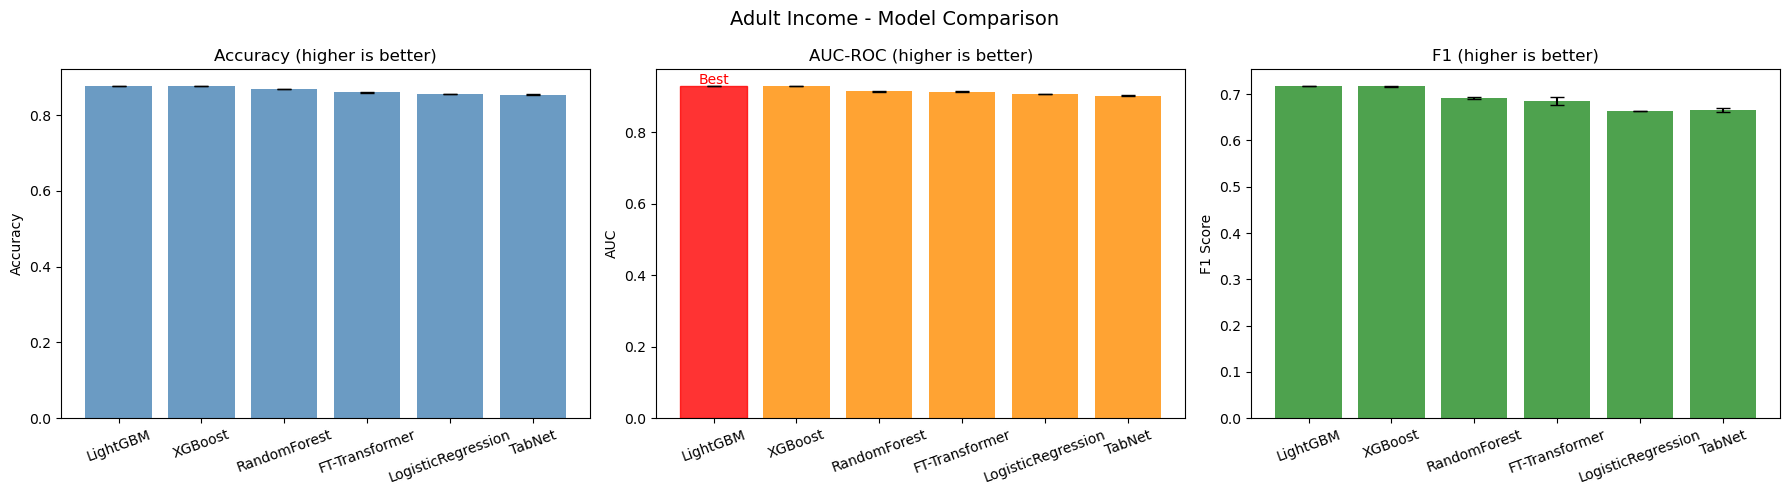

In [82]:
methods = ['LightGBM', 'XGBoost', 'RandomForest', 'FT-Transformer', 'LogisticRegression', 'TabNet']
summary = summary.reindex(methods)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(methods, summary['acc_mean'].values, yerr=summary['acc_std'].values,
            capsize=5, color='steelblue', alpha=0.8)
axes[0].set_title('Accuracy (higher is better)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylabel('Accuracy')

axes[1].bar(methods, summary['auc_mean'].values, yerr=summary['auc_std'].values,
            capsize=5, color='darkorange', alpha=0.8)
axes[1].set_title('AUC-ROC (higher is better)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel('AUC')

axes[2].bar(methods, summary['f1_mean'].values, yerr=summary['f1_std'].values,
            capsize=5, color='forestgreen', alpha=0.8)
axes[2].set_title('F1 (higher is better)')
axes[2].tick_params(axis='x', rotation=20)
axes[2].set_ylabel('F1 Score')

best_idx = summary['auc_mean'].idxmax()
best_pos = summary.index.get_loc(best_idx)

axes[1].patches[best_pos].set_color('red')

axes[1].text(
    best_pos,
    summary.loc[best_idx, 'auc_mean'] + 0.005,
    'Best',
    ha='center',
    color='red',
    fontsize=10
)

plt.suptitle('Adult Income - Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

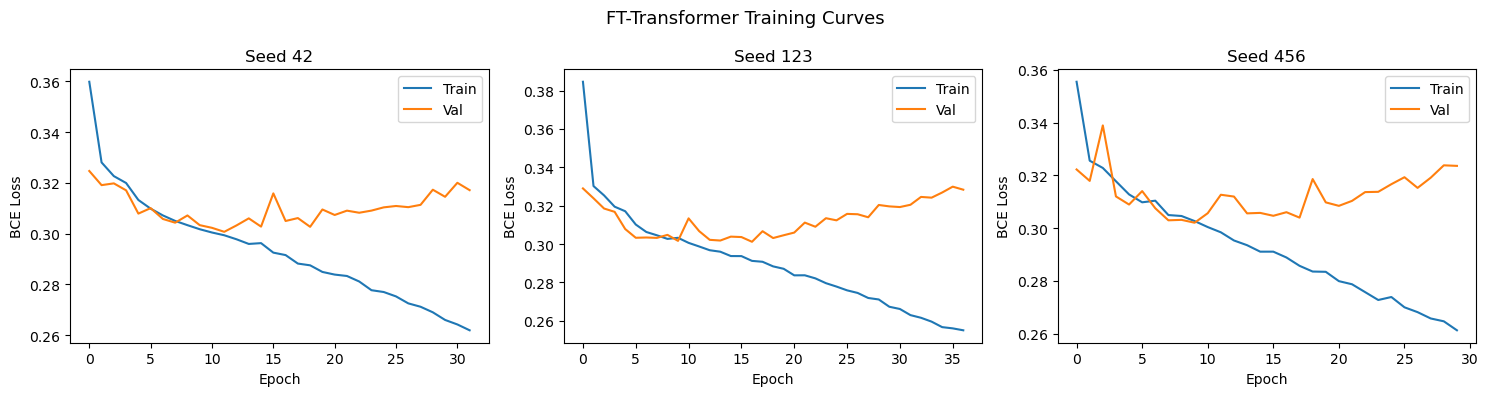

In [81]:
# FT-Transformer training curves
fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 4))
for ax, seed in zip(axes, SEEDS):
    tr_l, va_l = ft_train_curves[seed]
    ax.plot(tr_l, label='Train')
    ax.plot(va_l, label='Val')
    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
plt.suptitle('FT-Transformer Training Curves', fontsize=13)
plt.tight_layout()
plt.show()


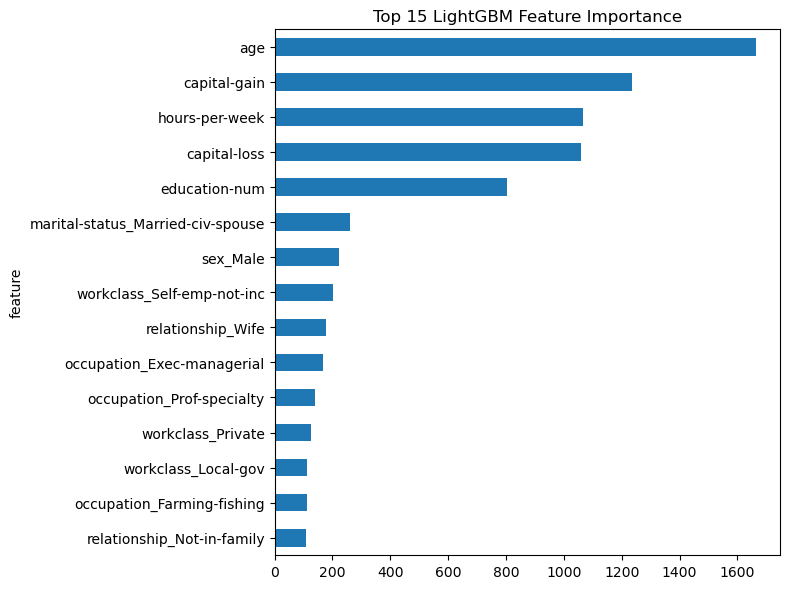

In [68]:
# Top 15 LightGBM feature importance
if lgb_model_last is not None:
    fi_df = pd.DataFrame({
        'feature': X_train_c.columns,
        'importance': lgb_model_last.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    fi_df = fi_df.sort_values('importance', ascending=True)

    fi_df.plot.barh(
        x='feature',
        y='importance',
        figsize=(8, 6),
        legend=False
    )

    plt.title('Top 15 LightGBM Feature Importance')
    plt.tight_layout()
    plt.show()

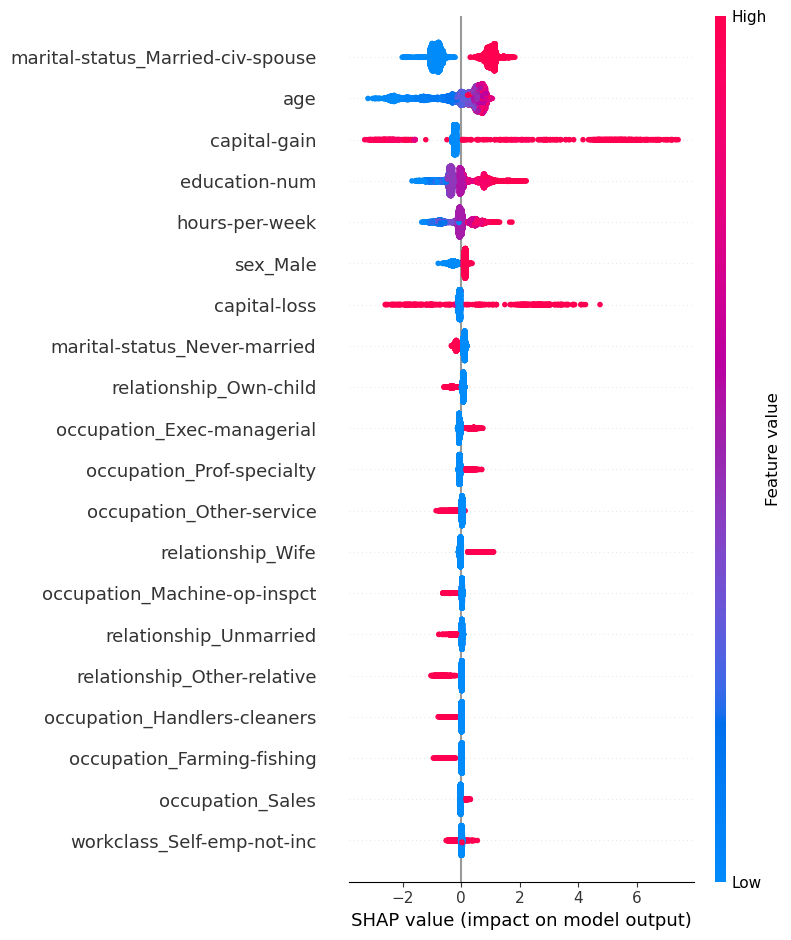

In [71]:
import shap

explainer = shap.TreeExplainer(lgb_model_last)
shap_values = explainer.shap_values(X_test_c)

shap.summary_plot(shap_values, X_test_c)

## Analysis & Conclusions

### Summary
We compared six methods on the UCI Adult Income binary classification task.

- **LightGBM** and **XGBoost** typically achieve top AUC-ROC on this dataset
  thanks to their ability to handle mixed numerical/categorical features.
- **FT-Transformer** leverages embeddings for categorical features, which can
  yield competitive AUC with sufficient training.
- **Logistic Regression** provides a fast and interpretable baseline.
- **TabNet** and **Random Forest** round out the comparison.

### Observations
- The dataset is moderately imbalanced (~24% positive); AUC-ROC is the most
  reliable metric here.
- OrdinalEncoding + StandardScaling is a straightforward preprocessing pipeline
  that works across all methods.
- 3-seed evaluation reveals model stability under random initialization.

### Next Steps
- One-hot encoding for tree methods vs. ordinal for neural methods.
- Class-weight adjustment to improve F1 for the minority class.
- SHAP explanations for the best-performing model.
